In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    precision_score, recall_score, confusion_matrix, classification_report,
    accuracy_score, f1_score, roc_auc_score, roc_curve, auc
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
np.random.seed(42)

data = pd.read_csv("/content/fetal_health.csv")

print(data.head())


   baseline value  accelerations  fetal_movement  uterine_contractions  \
0           120.0          0.000             0.0                 0.000   
1           132.0          0.006             0.0                 0.006   
2           133.0          0.003             0.0                 0.008   
3           134.0          0.003             0.0                 0.008   
4           132.0          0.007             0.0                 0.008   

   light_decelerations  severe_decelerations  prolongued_decelerations  \
0                0.000                   0.0                       0.0   
1                0.003                   0.0                       0.0   
2                0.003                   0.0                       0.0   
3                0.003                   0.0                       0.0   
4                0.000                   0.0                       0.0   

   abnormal_short_term_variability  mean_value_of_short_term_variability  \
0                             73.0

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

In [14]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
baseline value,2126.0,133.303857,9.840844,106.0,126.000,133.000,140.000,160.000
accelerations,2126.0,0.003178,0.003866,0.0,0.000,0.002,0.006,0.019
fetal_movement,2126.0,0.009481,0.046666,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2126.0,0.004366,0.002946,0.0,0.002,0.004,0.007,0.015
light_decelerations,2126.0,0.001889,0.002960,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2126.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2126.0,0.000159,0.000590,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2126.0,46.990122,17.192814,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2126.0,1.332785,0.883241,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2126.0,9.846660,18.396880,0.0,0.000,0.000,11.000,91.000


In [15]:
print("Class Distribution:")
print(data['fetal_health'].value_counts())

Class Distribution:
fetal_health
1.0    1655
2.0     295
3.0     176
Name: count, dtype: int64


<ipython-input-16-2ba408f23107>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='fetal_health', data=data, palette='viridis')


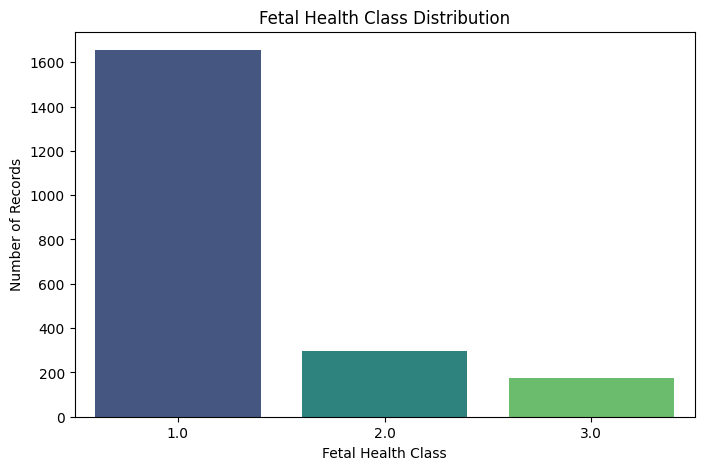

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(x='fetal_health', data=data, palette='viridis')

plt.title('Fetal Health Class Distribution')
plt.xlabel('Fetal Health Class')
plt.ylabel('Number of Records')

plt.show()

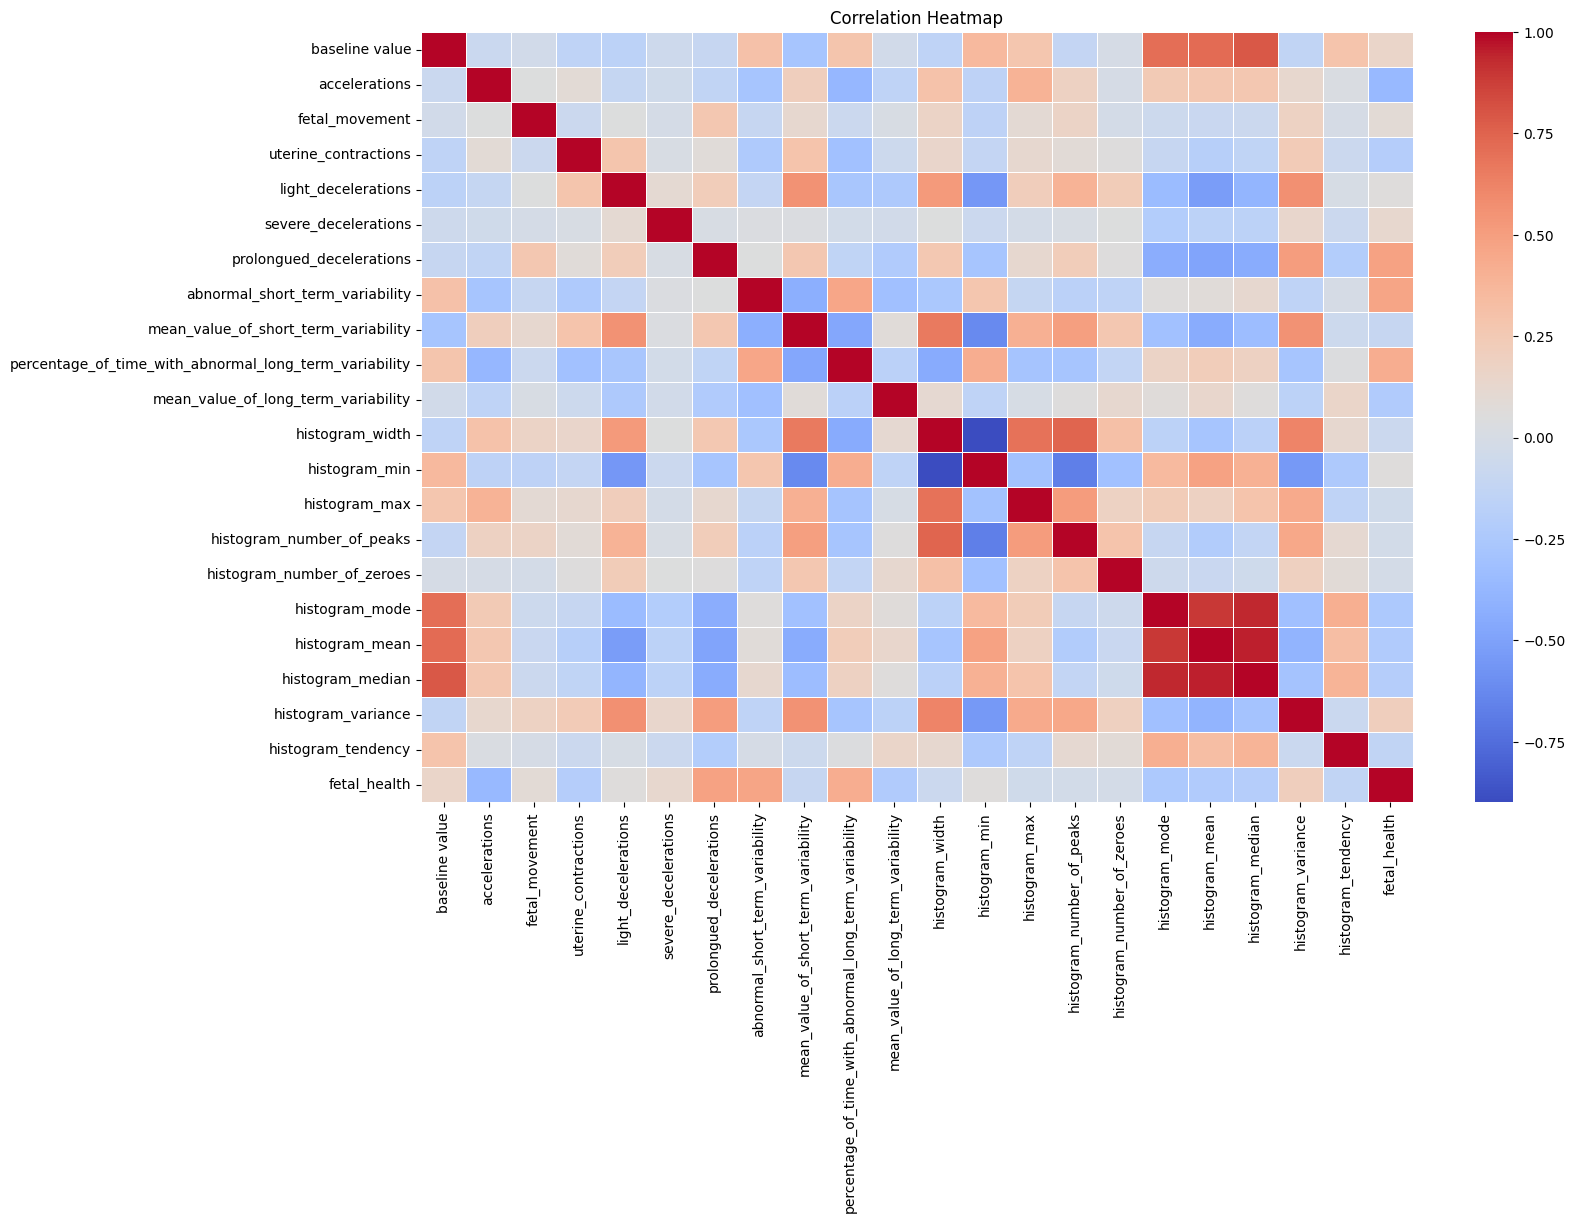

In [17]:
plt.figure(figsize=(16, 10))
correlation_matrix = data.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

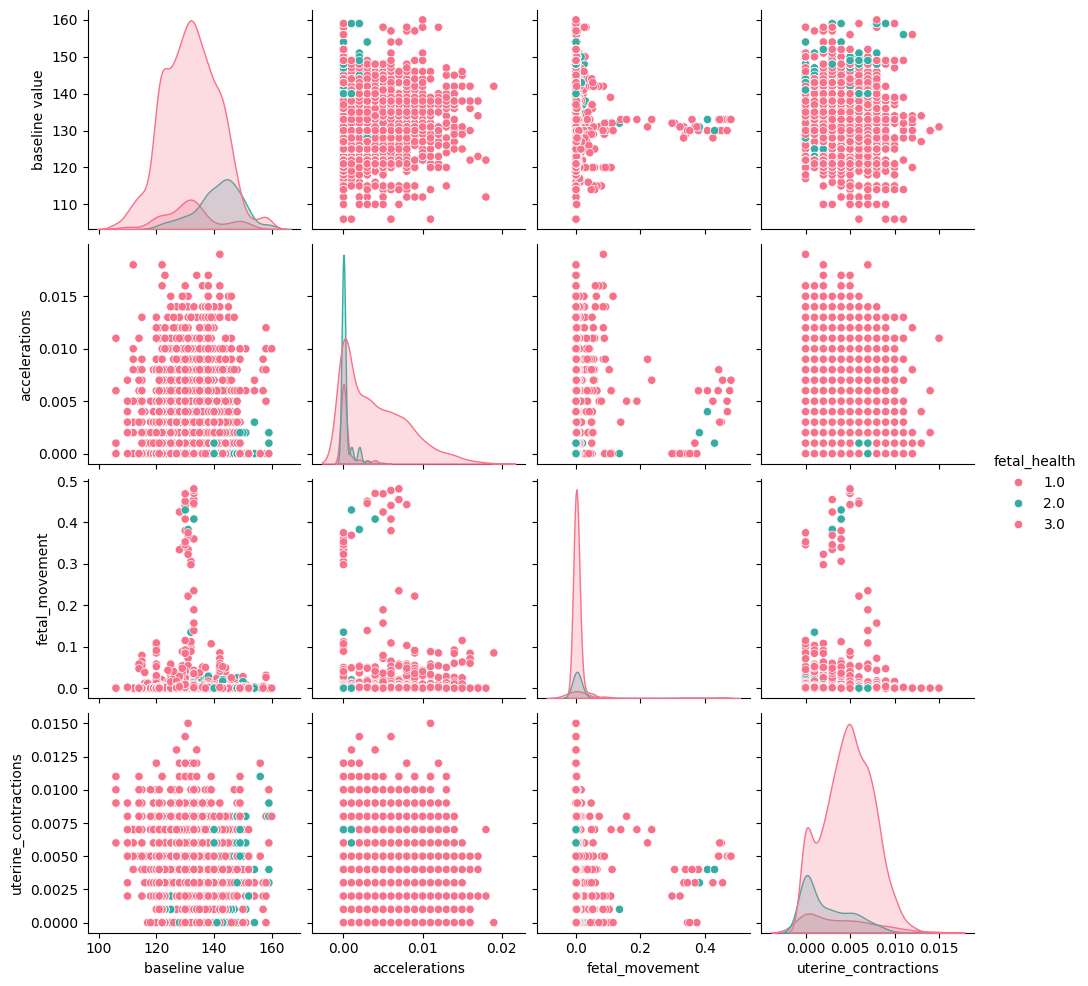

In [18]:
selected_features = ['baseline value', 'accelerations', 'fetal_movement', 'uterine_contractions', 'fetal_health']
sns.pairplot(data[selected_features], hue='fetal_health', palette='husl')
plt.show()


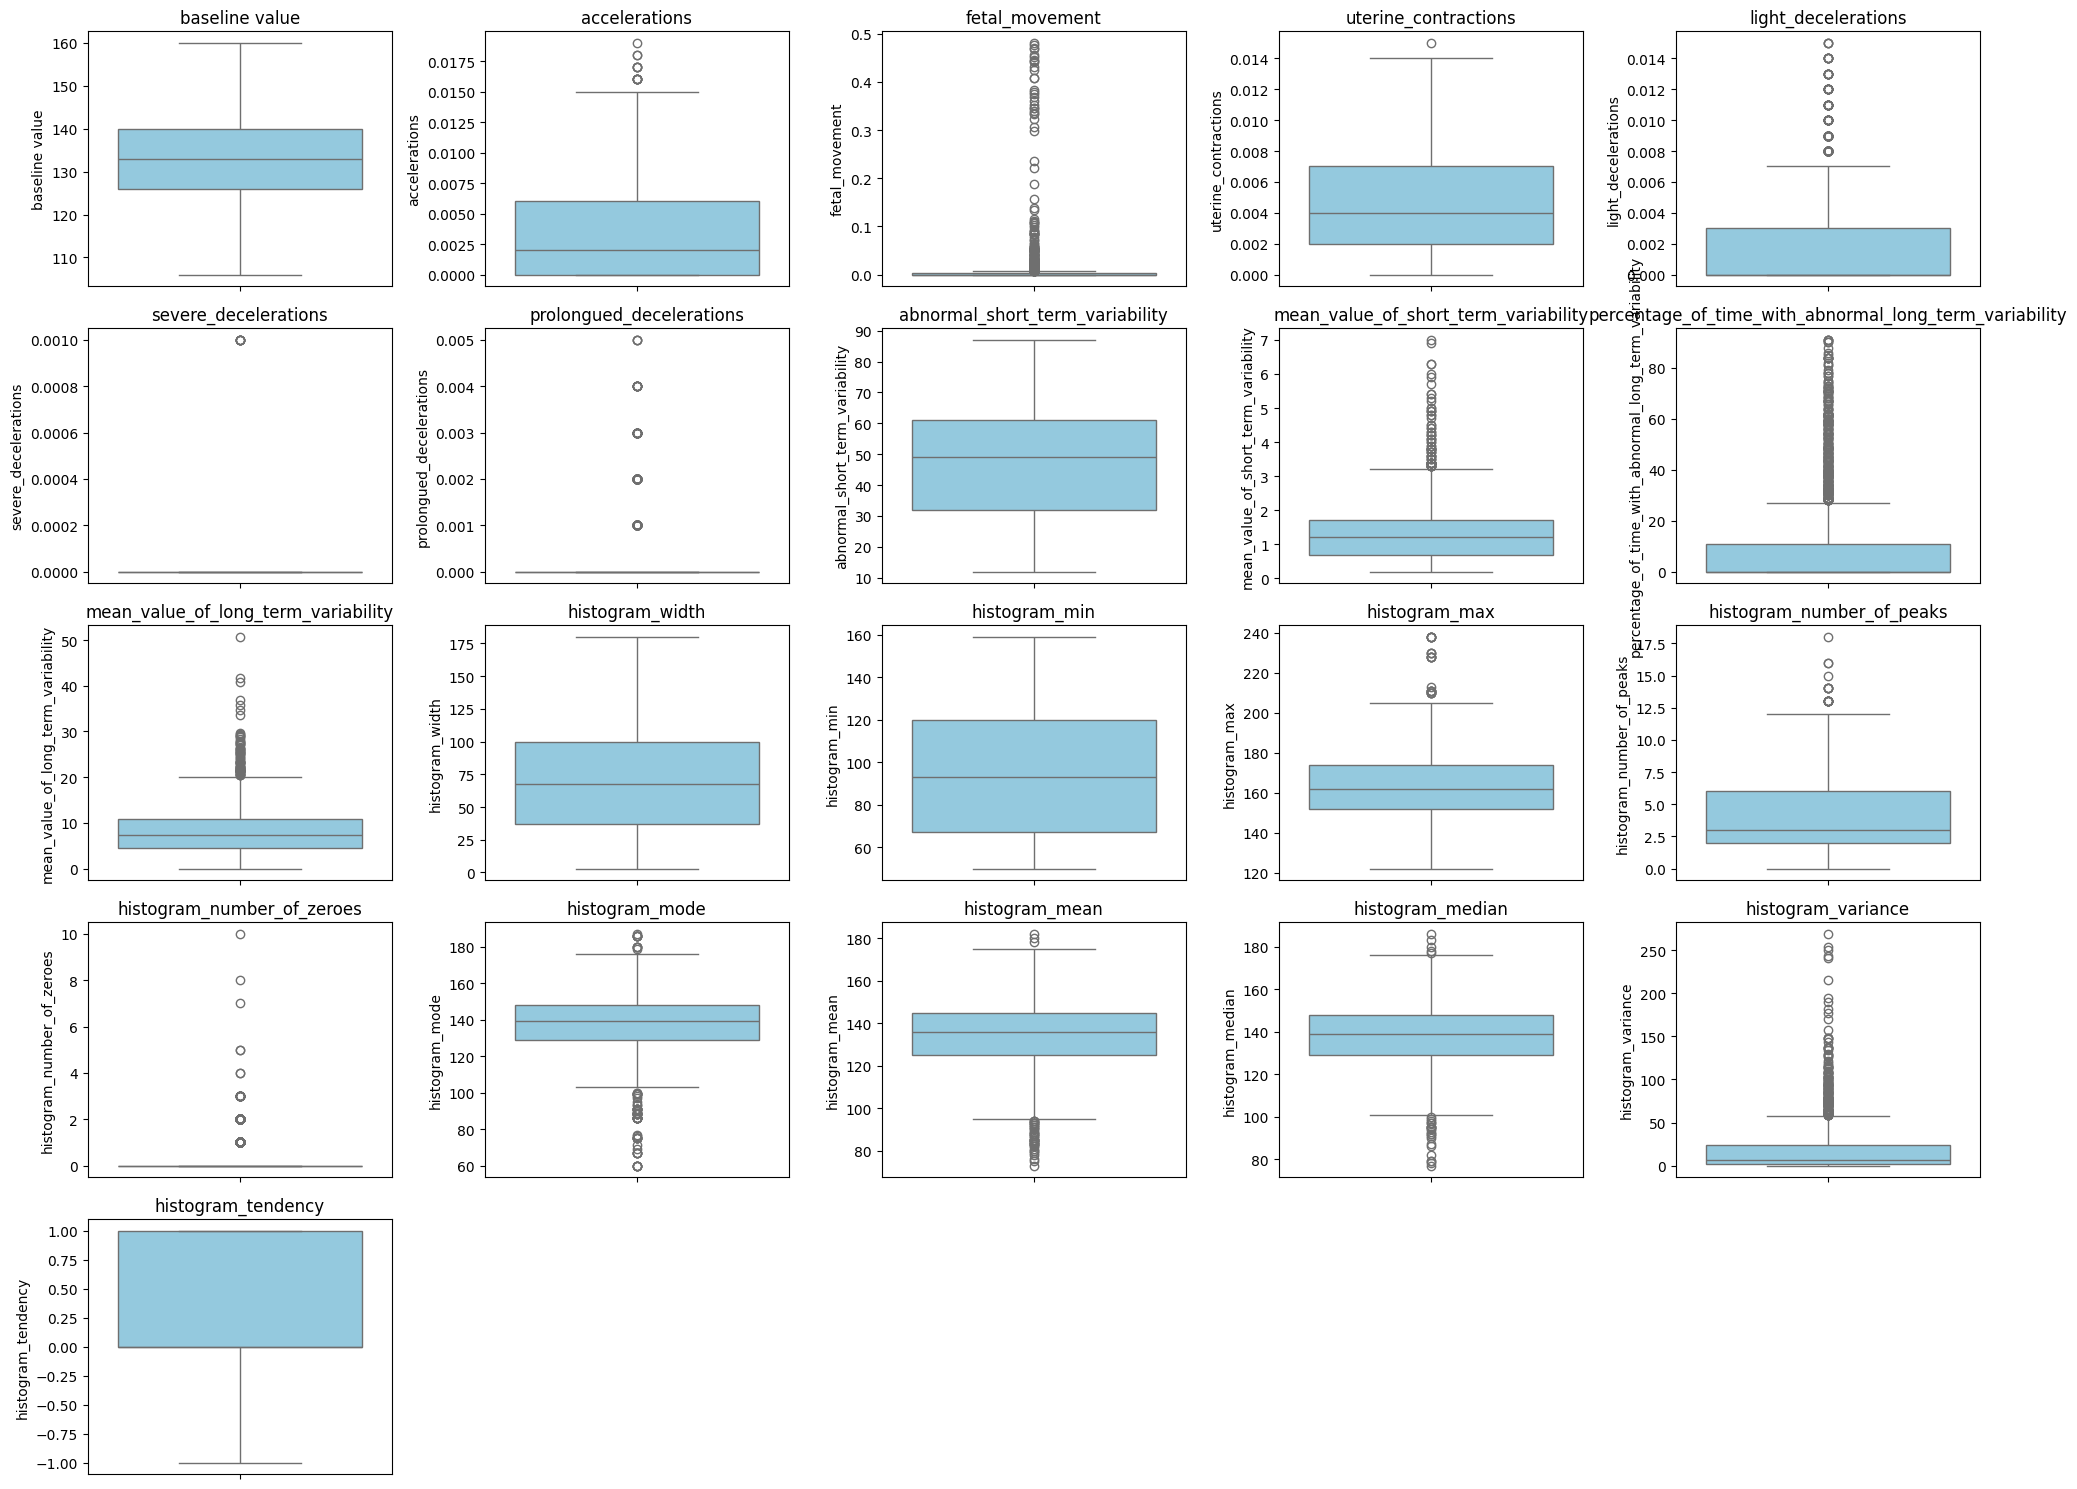

In [19]:
plt.figure(figsize=(20, 15))
for index, column in enumerate(data.columns[:-1], 1):
    plt.subplot(5, 5, index)
    sns.boxplot(data[column], color='skyblue')
    plt.title(column)
plt.tight_layout()
plt.show()

In [20]:
missing_values = data.isnull().sum()
print("\nMissing Values:")
print(missing_values)


Missing Values:
baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogram_mode         

In [21]:
grouped_data = data.groupby('fetal_health').mean()
print("\nStatistical Summary for Each Class:")
print(grouped_data.T)


Statistical Summary for Each Class:
fetal_health                                                 1.0         2.0  \
baseline value                                      1.319819e+02  141.684746   
accelerations                                       3.992145e-03    0.000275   
fetal_movement                                      7.963142e-03    0.008332   
uterine_contractions                                4.780665e-03    0.002390   
light_decelerations                                 1.941390e-03    0.000536   
severe_decelerations                                6.042296e-07    0.000000   
prolongued_decelerations                            5.135952e-05    0.000095   
abnormal_short_term_variability                     4.246586e+01   61.901695   
mean_value_of_short_term_variability                1.430634e+00    0.638983   
percentage_of_time_with_abnormal_long_term_vari...  5.044713e+00   29.030508   
mean_value_of_long_term_variability                 8.705498e+00    8.026102   
his

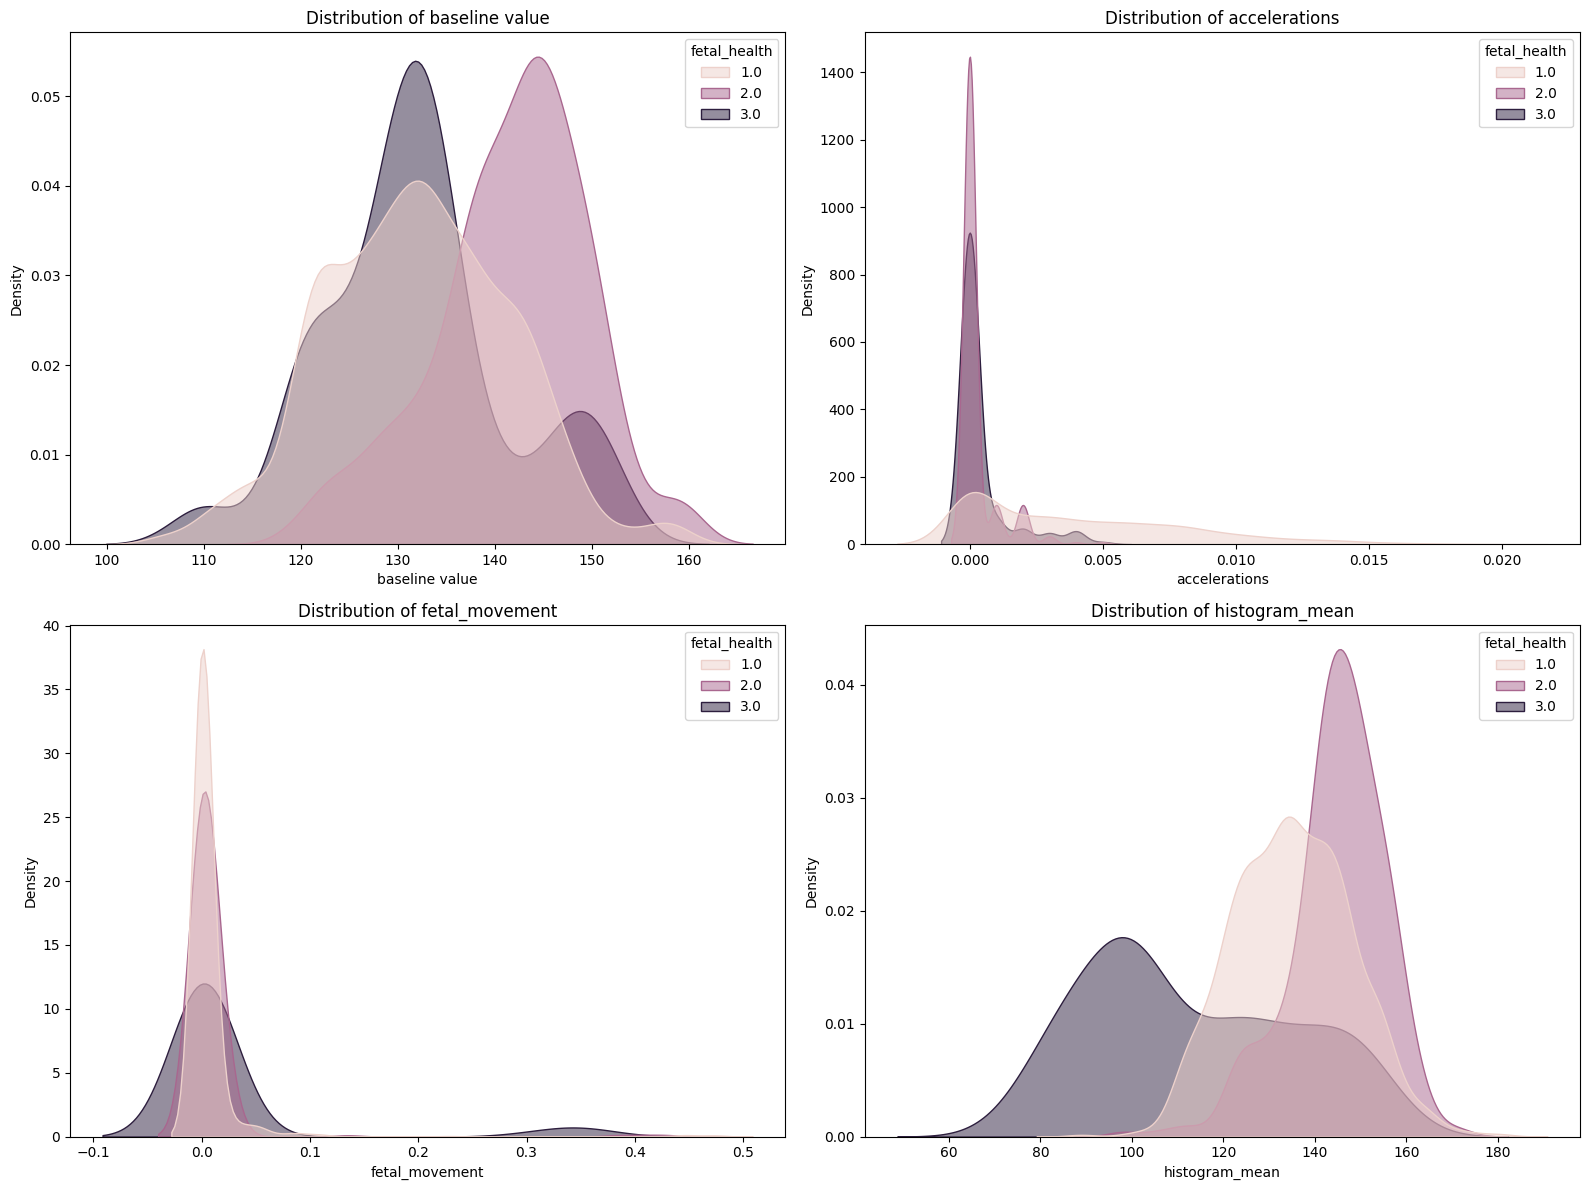

In [22]:
data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

features_to_plot = ['baseline value', 'accelerations', 'fetal_movement', 'histogram_mean']
plt.figure(figsize=(16, 12))

for i, feature in enumerate(features_to_plot, 1):
    plt.subplot(2, 2, i)
    sns.kdeplot(
        data=data,
        x=feature,
        hue="fetal_health",
        fill=True,
        common_norm=False,
        alpha=0.5
    )
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')

plt.tight_layout()
plt.show()

In [23]:
scaler = StandardScaler()
X = data.drop('fetal_health', axis=1)
y = data['fetal_health']
X_scaled = scaler.fit_transform(X)

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

#**Random Forest Model**


In [25]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_score = roc_auc_score(y_test, model.predict_proba(X_test), multi_class='ovr')
print(f"ROC-AUC Score: {roc_score}")

Confusion Matrix:
[[326   6   1]
 [ 13  50   1]
 [  1   1  27]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.96      0.98      0.97       333
         2.0       0.88      0.78      0.83        64
         3.0       0.93      0.93      0.93        29

    accuracy                           0.95       426
   macro avg       0.92      0.90      0.91       426
weighted avg       0.94      0.95      0.94       426

ROC-AUC Score: 0.9855745685829805


In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)  # Display the best parameters

Best Parameters: {'max_depth': None, 'n_estimators': 200}


In [28]:
optimized_rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
optimized_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [29]:
y_pred = optimized_rf.predict(X_test)
y_pred_proba = optimized_rf.predict_proba(X_test)

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_score = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"ROC-AUC Score: {roc_score}")

Confusion Matrix:
[[327   5   1]
 [ 11  52   1]
 [  1   1  27]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.96      0.98      0.97       333
         2.0       0.90      0.81      0.85        64
         3.0       0.93      0.93      0.93        29

    accuracy                           0.95       426
   macro avg       0.93      0.91      0.92       426
weighted avg       0.95      0.95      0.95       426

ROC-AUC Score: 0.9867802486938887


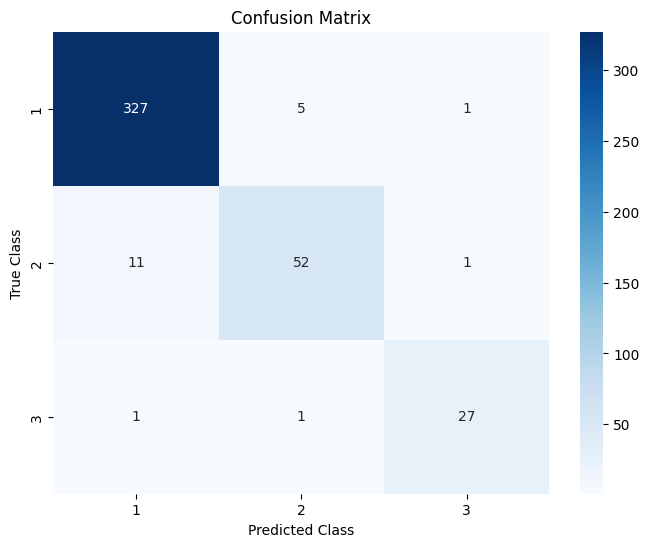

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", xticklabels=[1, 2, 3], yticklabels=[1, 2, 3])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

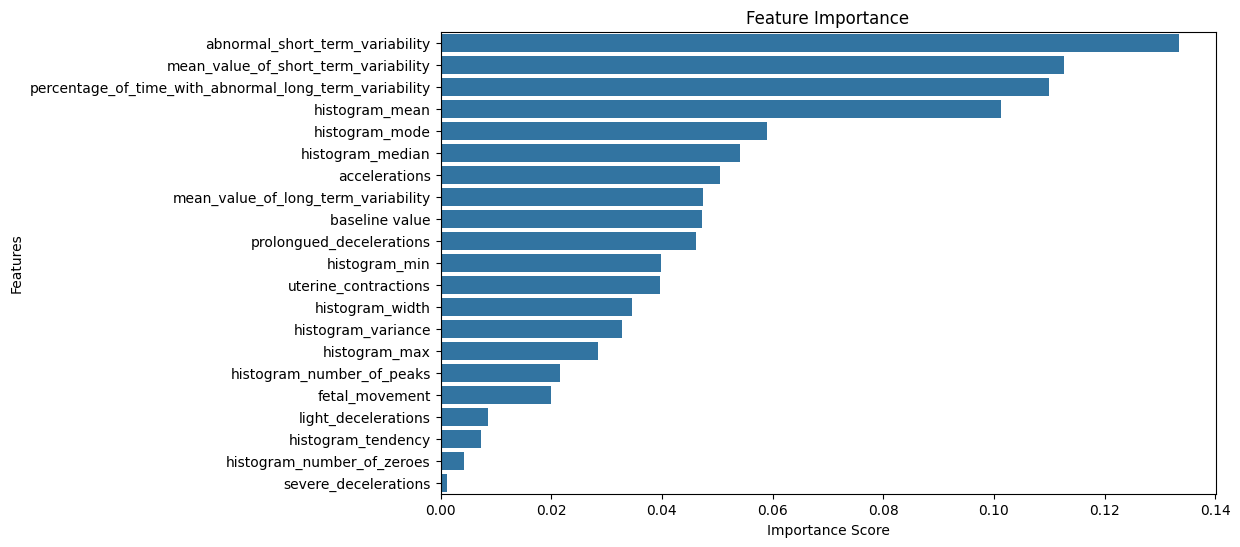

In [32]:
feature_importances = pd.Series(optimized_rf.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

#**Decision Tree Classifier**

In [33]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)
y_pred_proba = dt_model.predict_proba(X_test)

In [34]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_score = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"ROC-AUC Score: {roc_score}")

Confusion Matrix:
[[314  17   2]
 [ 12  52   0]
 [  2   0  27]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.96      0.94      0.95       333
         2.0       0.75      0.81      0.78        64
         3.0       0.93      0.93      0.93        29

    accuracy                           0.92       426
   macro avg       0.88      0.90      0.89       426
weighted avg       0.92      0.92      0.92       426

ROC-AUC Score: 0.9139901136584658


In [35]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search_dt.fit(X_train, y_train)

print("Best Parameters:", grid_search_dt.best_params_)

# Train the optimized Decision Tree model
optimized_dt = DecisionTreeClassifier(
    criterion=grid_search_dt.best_params_['criterion'],
    max_depth=grid_search_dt.best_params_['max_depth'],
    min_samples_split=grid_search_dt.best_params_['min_samples_split'],
    min_samples_leaf=grid_search_dt.best_params_['min_samples_leaf'],
    random_state=42
)
optimized_dt.fit(X_train, y_train)

Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


DecisionTreeClassifier(criterion='entropy', random_state=42)

In [36]:
y_pred = optimized_dt.predict(X_test)
y_pred_proba = optimized_dt.predict_proba(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_score = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"ROC-AUC Score: {roc_score}")

Confusion Matrix:
[[318  12   3]
 [ 13  51   0]
 [  1   2  26]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.96      0.95      0.96       333
         2.0       0.78      0.80      0.79        64
         3.0       0.90      0.90      0.90        29

    accuracy                           0.93       426
   macro avg       0.88      0.88      0.88       426
weighted avg       0.93      0.93      0.93       426

ROC-AUC Score: 0.9086022227453566


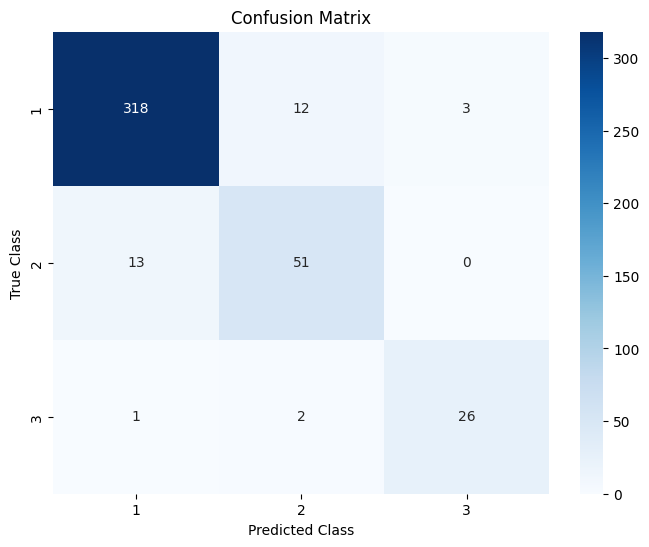

In [37]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", xticklabels=[1, 2, 3], yticklabels=[1, 2, 3])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

In [38]:
feature_importances_dt = pd.Series(optimized_dt.feature_importances_, index=X.columns)
feature_importances_dt = feature_importances_dt.sort_values(ascending=False)

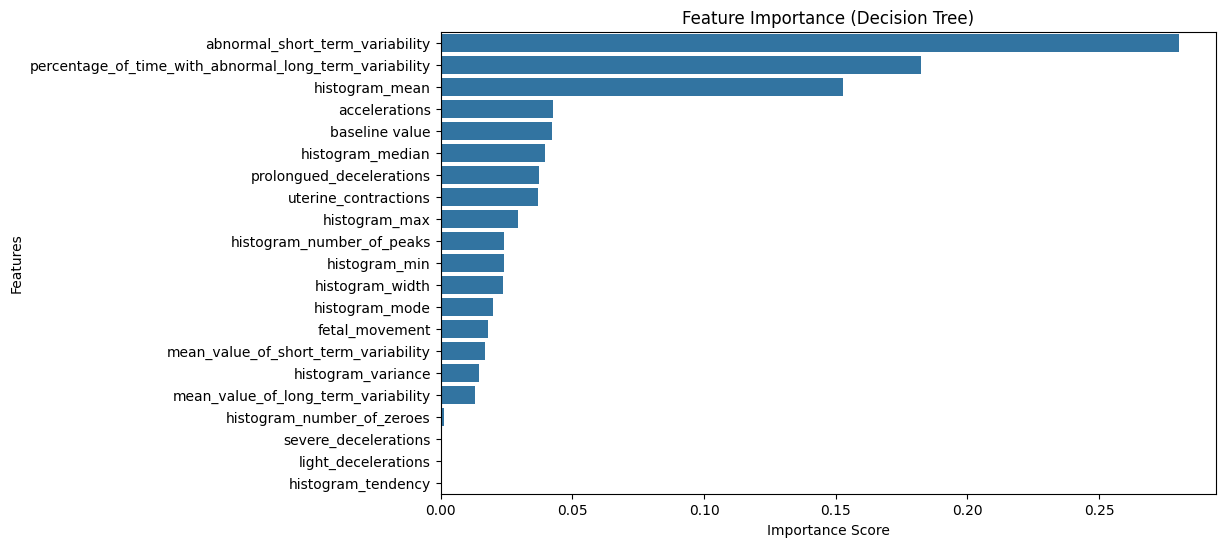

In [39]:
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_dt, y=feature_importances_dt.index)
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

#**K-Nearest Neighbors Classifier**

In [40]:
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)
y_pred_proba = knn_model.predict_proba(X_test)

In [41]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_score = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"ROC-AUC Score: {roc_score}")

Confusion Matrix:
[[324   7   2]
 [ 16  44   4]
 [  4   3  22]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.94      0.97      0.96       333
         2.0       0.81      0.69      0.75        64
         3.0       0.79      0.76      0.77        29

    accuracy                           0.92       426
   macro avg       0.85      0.81      0.82       426
weighted avg       0.91      0.92      0.91       426

ROC-AUC Score: 0.9445031424556266


In [42]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search_knn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search_knn.fit(X_train, y_train)

print("Best Parameters:", grid_search_knn.best_params_)

# Train the optimized KNN model
optimized_knn = KNeighborsClassifier(
    n_neighbors=grid_search_knn.best_params_['n_neighbors'],
    weights=grid_search_knn.best_params_['weights'],
    metric=grid_search_knn.best_params_['metric']
)
optimized_knn.fit(X_train, y_train)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}


KNeighborsClassifier(metric='manhattan', n_neighbors=3, weights='distance')

In [43]:
y_pred = optimized_knn.predict(X_test)
y_pred_proba = optimized_knn.predict_proba(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_score = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"ROC-AUC Score: {roc_score}")

Confusion Matrix:
[[323   9   1]
 [ 14  47   3]
 [  2   2  25]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.95      0.97      0.96       333
         2.0       0.81      0.73      0.77        64
         3.0       0.86      0.86      0.86        29

    accuracy                           0.93       426
   macro avg       0.88      0.86      0.86       426
weighted avg       0.93      0.93      0.93       426

ROC-AUC Score: 0.9486190162993163


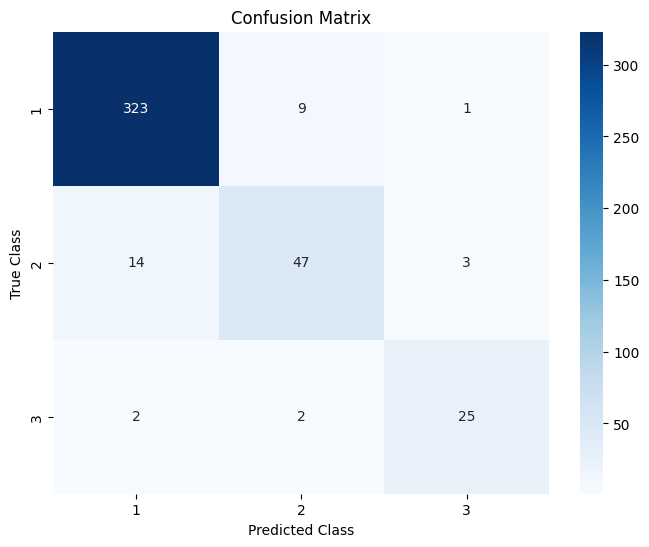

In [44]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", xticklabels=[1, 2, 3], yticklabels=[1, 2, 3])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

#**Logistic Regression.**

In [45]:
logreg_model = LogisticRegression(multi_class='ovr', solver='liblinear', random_state=42)
logreg_model.fit(X_train, y_train)
y_pred = logreg_model.predict(X_test)
y_pred_proba = logreg_model.predict_proba(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


In [46]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_score = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"ROC-AUC Score: {roc_score}")

Confusion Matrix:
[[314  16   3]
 [ 19  42   3]
 [  2   5  22]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.94      0.94      0.94       333
         2.0       0.67      0.66      0.66        64
         3.0       0.79      0.76      0.77        29

    accuracy                           0.89       426
   macro avg       0.80      0.79      0.79       426
weighted avg       0.89      0.89      0.89       426

ROC-AUC Score: 0.9557622149192841


In [47]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
    'solver': ['liblinear', 'lbfgs'],  # Solvers for optimization
    'penalty': ['l1', 'l2']  # Regularization type
}

grid_search_lr = GridSearchCV(LogisticRegression(multi_class='ovr', random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search_lr.fit(X_train, y_train)

print("Best Parameters:", grid_search_lr.best_params_)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

Best Parameters: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solve

In [48]:
optimized_lr = LogisticRegression(
    C=grid_search_lr.best_params_['C'],
    solver=grid_search_lr.best_params_['solver'],
    penalty=grid_search_lr.best_params_['penalty'],
    multi_class='ovr',
    random_state=42
)
optimized_lr.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=100, multi_class='ovr', random_state=42)

In [49]:
y_pred = optimized_lr.predict(X_test)
y_pred_proba = optimized_lr.predict_proba(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_score = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"ROC-AUC Score: {roc_score}")


Confusion Matrix:
[[315  16   2]
 [ 20  40   4]
 [  3   4  22]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.93      0.95      0.94       333
         2.0       0.67      0.62      0.65        64
         3.0       0.79      0.76      0.77        29

    accuracy                           0.88       426
   macro avg       0.79      0.78      0.79       426
weighted avg       0.88      0.88      0.88       426

ROC-AUC Score: 0.954476300101776


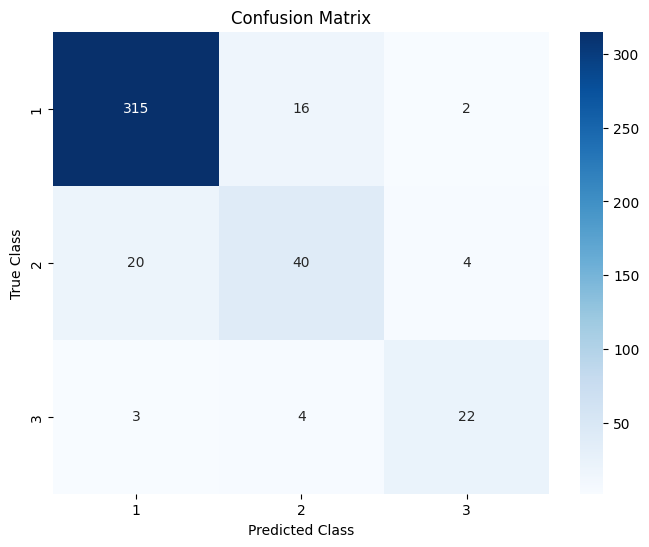

In [50]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", xticklabels=[1, 2, 3], yticklabels=[1, 2, 3])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

#**Extra Trees Classifier**

In [51]:
from sklearn.ensemble import ExtraTreesClassifier

In [52]:
et_model = ExtraTreesClassifier(random_state=42)
et_model.fit(X_train, y_train)
y_pred = et_model.predict(X_test)
y_pred_proba = et_model.predict_proba(X_test)

In [53]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_score = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"ROC-AUC Score: {roc_score}")

Confusion Matrix:
[[326   6   1]
 [ 12  50   2]
 [  1   3  25]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.96      0.98      0.97       333
         2.0       0.85      0.78      0.81        64
         3.0       0.89      0.86      0.88        29

    accuracy                           0.94       426
   macro avg       0.90      0.87      0.89       426
weighted avg       0.94      0.94      0.94       426

ROC-AUC Score: 0.9832700893815685


In [54]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search_et = GridSearchCV(ExtraTreesClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search_et.fit(X_train, y_train)

print("Best Parameters:", grid_search_et.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [55]:
optimized_et = ExtraTreesClassifier(
    n_estimators=grid_search_et.best_params_['n_estimators'],
    max_depth=grid_search_et.best_params_['max_depth'],
    min_samples_split=grid_search_et.best_params_['min_samples_split'],
    min_samples_leaf=grid_search_et.best_params_['min_samples_leaf'],
    criterion=grid_search_et.best_params_['criterion'],
    random_state=42
)
optimized_et.fit(X_train, y_train)

ExtraTreesClassifier(max_depth=20, n_estimators=200, random_state=42)

In [56]:
y_pred = optimized_et.predict(X_test)
y_pred_proba = optimized_et.predict_proba(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

roc_score = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"ROC-AUC Score: {roc_score}")

Confusion Matrix:
[[327   5   1]
 [ 14  48   2]
 [  2   3  24]]

Classification Report:
              precision    recall  f1-score   support

         1.0       0.95      0.98      0.97       333
         2.0       0.86      0.75      0.80        64
         3.0       0.89      0.83      0.86        29

    accuracy                           0.94       426
   macro avg       0.90      0.85      0.87       426
weighted avg       0.93      0.94      0.93       426

ROC-AUC Score: 0.9835600953435647


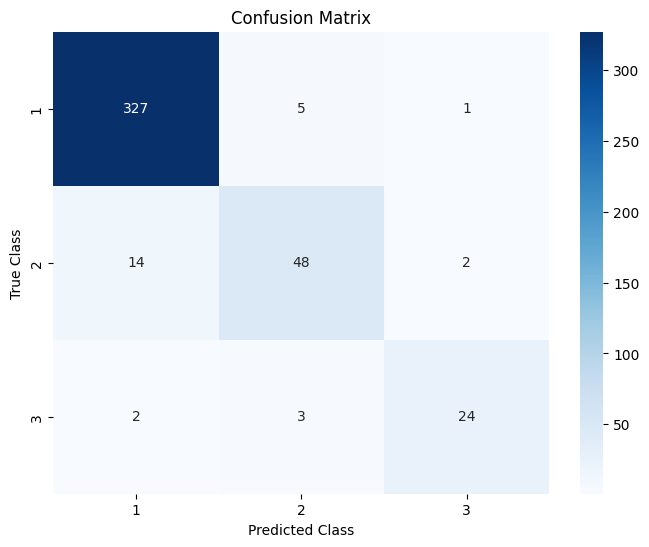

In [57]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", xticklabels=[1, 2, 3], yticklabels=[1, 2, 3])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

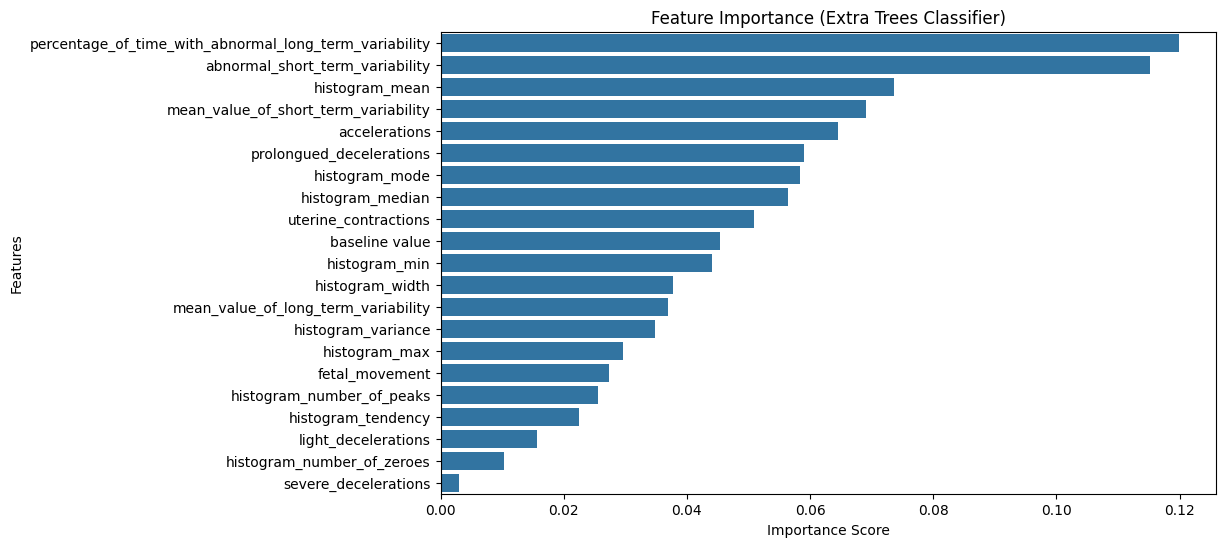

In [58]:
feature_importances_et = pd.Series(optimized_et.feature_importances_, index=X.columns)
feature_importances_et = feature_importances_et.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances_et, y=feature_importances_et.index)
plt.title("Feature Importance (Extra Trees Classifier)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

Training Random Forest...
Random Forest Accuracy: 0.9460093896713615
Random Forest ROC-AUC Score: 0.9855745685829805
Random Forest Confusion Matrix:
[[326   6   1]
 [ 13  50   1]
 [  1   1  27]]

Training Extra Trees...
Extra Trees Accuracy: 0.9413145539906104
Extra Trees ROC-AUC Score: 0.9832700893815685
Extra Trees Confusion Matrix:
[[326   6   1]
 [ 12  50   2]
 [  1   3  25]]

Training Decision Tree...
Decision Tree Accuracy: 0.9225352112676056
Decision Tree ROC-AUC Score: 0.9139901136584658
Decision Tree Confusion Matrix:
[[314  17   2]
 [ 12  52   0]
 [  2   0  27]]

Training KNN...
KNN Accuracy: 0.9154929577464789
KNN ROC-AUC Score: 0.9445031424556266
KNN Confusion Matrix:
[[324   7   2]
 [ 16  44   4]
 [  4   3  22]]

Training Logistic Regression...
Logistic Regression Accuracy: 0.8873239436619719
Logistic Regression ROC-AUC Score: 0.9557622149192841
Logistic Regression Confusion Matrix:
[[314  16   3]
 [ 19  42   3]
 [  2   5  22]]

Training SVM...
SVM Accuracy: 0.903755868544

<ipython-input-59-d54ab03ad699>:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Model", data=results_df.sort_values(by="Accuracy", ascending=False), palette="viridis")


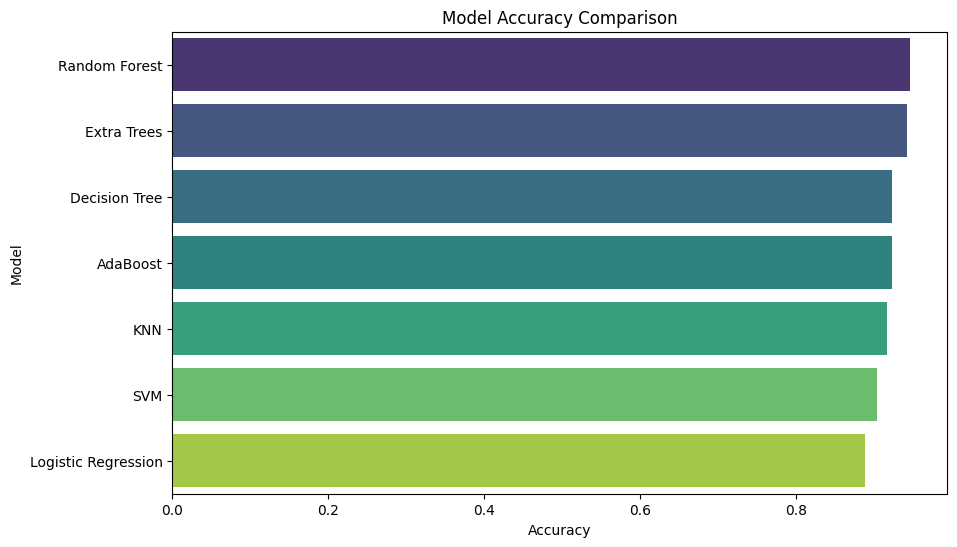

In [59]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(solver='liblinear', random_state=42),
    "SVM": SVC(probability=True, random_state=42),  # Enable probability for ROC-AUC
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

# Dictionary to store results
results = {
    "Model": [],
    "Accuracy": [],
    "ROC-AUC": [],
    "Confusion Matrix": [],
    "Classification Report": []
}

# Evaluate each model
for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr') if y_pred_proba is not None else "N/A"
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, output_dict=True)

    # Store results
    results["Model"].append(model_name)
    results["Accuracy"].append(accuracy)
    results["ROC-AUC"].append(roc_auc)
    results["Confusion Matrix"].append(conf_matrix)
    results["Classification Report"].append(class_report)

    # Print details
    print(f"{model_name} Accuracy: {accuracy}")
    if roc_auc != "N/A":
        print(f"{model_name} ROC-AUC Score: {roc_auc}")
    print(f"{model_name} Confusion Matrix:\n{conf_matrix}\n")

# Display results as a DataFrame
results_df = pd.DataFrame({
    "Model": results["Model"],
    "Accuracy": results["Accuracy"],
    "ROC-AUC": results["ROC-AUC"]
})
print("\nSummary of Results:")
print(results_df)

# Visualizing Accuracy Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x="Accuracy", y="Model", data=results_df.sort_values(by="Accuracy", ascending=False), palette="viridis")
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.show()

In [60]:
import pickle
pickle.dump(optimized_rf, open('model.pkl', 'wb'))